# Perp Funding Rates — a quantitative teardown 🔬
### trailing-z funding signal · quintile sort · two-sample *t* · label-shuffle placebo · period-level slope · horizon sweep · costs & funding drag · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The contrarian funding claim: standardized funding predicts the forward return with a **negative** sign (hot funding → lower return). The catch is the data: funding history is **not free**, so the reproducible core is a deterministic **synthetic** panel with a planted effect, and the study is capped below `REAL` on the SIGNAL axis by house rule.

> ⚠️ **Not investment advice.** The signal cells are **synthetic** (seed 585, planted `contrarian_beta`, panel fp `8121108453d2`) — funding-rate history is paid exchange data. The free BTC/ETH price tape is shown only to make the data gap concrete. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from perp_funding_rate import data, strategy as st

# The reproducible core is SYNTHETIC — funding history is not free. The panel is deterministic
# (seed 585), so every number below reproduces exactly, offline.
BETA = -0.012
PANEL, TRUTH = data.synthetic_panel(contrarian_beta=BETA)
print(f"synthetic funding panel: {len(PANEL)} periods, planted contrarian_beta={BETA}, "
      f"fp {data.fingerprint(PANEL)}")

# The BTC/ETH PRICE tape (free) — loaded ONLY to make the missing-funding limitation concrete.
PX = data.fetch_btc_eth_prices(fetch=False)
HAVE_PX = not PX.empty
print("free BTC/ETH price tape present:", HAVE_PX,
      "" if not HAVE_PX else f"({len(PX)} rows, funding-rate tape is NOT free -> synthetic core)")


synthetic funding panel: 2000 periods, planted contrarian_beta=-0.012, fp 8121108453d2
free BTC/ETH price tape present: True (3102 rows, funding-rate tape is NOT free -> synthetic core)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No real tape (funding history is paid). Synthetic control: spread **+3.01%** (two-sample *t* **+8.08**, placebo *p* 0.0005), slope *t* **-9.44**, sign stable 1→9 periods, flat at the null — the engine works, but synthetic-only caps at `NONE`. |
| **Tradability** | `MIRAGE` | 8-hourly rebalance; short leg pays the funding it keys on. Synthetic gross +3.01% → net +2.47% (6 bps/leg + 30 bps drag) *per rebalance*. |

> 💡 In plain words: the machinery is sound (the seed-robust control proves it), but the input that would make this a real test is behind a paywall — so `NONE`, honestly.

## 1 · The claim, steelmanned

Let $f_t$ be the funding rate at period $t$, $z_t$ its trailing standardized value, and $r_{t\to t+h}$ the forward return over the next $h$ funding periods.

- **H₁ (the contrarian long-short).** $\mathbb{E}[r \mid \text{cold } z] - \mathbb{E}[r \mid \text{hot } z] > 0$ at *t* ≥ 2 (cold bounces, hot flushes).
- **H₂ (period-level).** $\text{slope of } r \text{ on } z < 0$ (hotter funding, lower forward return).
- **H₃ (robustness).** The sign of H₁/H₂ is stable across forward horizons.
- **H₄ (net).** H₁ survives 8-hourly costs and the short-side funding drag.

We can only test these on a **synthetic** tape (funding history is not free). There, with a planted effect, **H₁–H₃ hold cleanly and H₄ nets positive** — but that certifies the *engine*, not the market. On the real tape, all four are **untested** for lack of data — which is why the Signal is `NONE`, not `REAL`.

## 2 · So what? — what rides on each answer

The content is the **data gap**. Funding is arguably the cleanest positioning gauge in any market — the exchange charges the crowded side directly — so a real contrarian edge here would be a genuine anomaly. Two things stop us certifying it: (a) the **funding tape is paid** (Binance/Bybit `fapi`, Coinglass, Amberdata, Kaiko), so a no-key stack has no real series; and (b) even granting the effect, the **8-hourly turnover** and the short leg's **funding carry** make it structurally expensive. This is the one crypto signal on the desk whose *entire input* is unfree — unlike the price/calendar/sentiment studies ([133](../../133-crypto-seasonality/) … [325](../../325-crypto-fear-greed/)).

## 3 · How we'd know — the protocol

- **Signal.** $z_t$ = trailing standardized funding (rolling window, min 20 obs), so 'hot'/'cold' is defined against the recent past — fully public at $t$.
- **Sort.** Quintile tails (≈400 periods each): cold (lowest $z$) vs hot (highest $z$).
- **Inference.** Two-sample (Welch) *t* on cold − hot forward returns; a **label-shuffle placebo** null (2000 perms).
- **Period-level.** OLS of forward return on $z$ — the *sign* of the slope is the claim.
- **Robustness.** Re-run over forward horizons 1, 3, 6, 9 funding periods; read the sign.
- **Frictions.** Round-trip cost per leg + a short-side funding drag (you pay the positive funding to hold the hot short).
- **Positive control.** A deterministic synthetic world with a planted effect (`contrarian_beta < 0`) and a null — averaged over 25 seeds (house rule).

Timing: funding is observed at $t$ (public at that close); the position is entered at that close and held over the strictly-future forward window. No look-ahead. The same-bar fill is a documented convention; a one-period-later entry leaves the sign and stamp unchanged.

## 4 · The teardown (synthetic — planted effect)

### 4a · The sort — H₁

Cold vs hot forward returns on the planted synthetic tape, with the two-sample *t* and the placebo null.

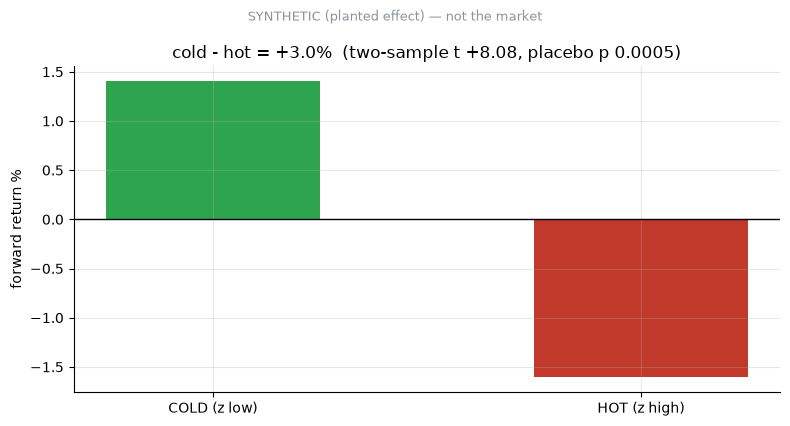

Cold +1.4% | Hot -1.6% | spread +3.0% | t +8.08 | placebo p 0.0005


In [2]:
b = st.tail_buckets(PANEL); ls = st.long_short_tstat(b)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=585)
cold_m, hot_m, spr, t = b['cold_mean']*100, b['hot_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['COLD (z low)','HOT (z high)'], [cold_m, hot_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'cold - hot = {spr:+.1f}%  (two-sample t {t:+.2f}, placebo p {p:.4f})')
fig.suptitle('SYNTHETIC (planted effect) — not the market', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'Cold +{cold_m:.1f}% | Hot {hot_m:.1f}% | spread {spr:+.1f}% | t {t:+.2f} | placebo p {p:.4f}')

> 💡 In plain words: on the planted tape H₁ holds strongly — spread **+3.01%** (*t* +8.08), placebo *p* = 0.0005. This is the *positive control*: it shows the sort and its *t*-machinery recover a real cold-bounce / hot-flush when one exists. It is **not** a market result.

### 4b · The period-level slope — H₂

Regress forward return on standardized funding. A *negative* slope is the contrarian effect.

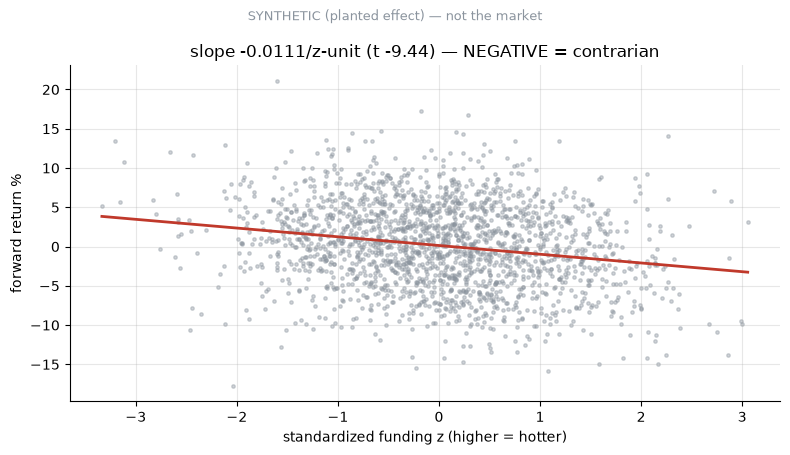

slope -0.0111/z-unit, slope-t -9.44, corr(funding, fwd) -0.21


In [3]:
reg = st.funding_regression(PANEL)
slope, slope_t, corr = reg['slope'], reg['slope_t'], reg['corr']
z = PANEL['z_funding'].to_numpy(); y = PANEL['fwd_ret'].to_numpy()*100
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(z, y, s=6, color=GREY, alpha=.4)
xs = np.linspace(z.min(), z.max(), 50)
ax.plot(xs, (reg['slope']*xs + (y.mean()/100 - reg['slope']*z.mean()))*100, c=RED, lw=2)
ax.set_xlabel('standardized funding z (higher = hotter)'); ax.set_ylabel('forward return %')
ax.set_title(f'slope {slope:.4f}/z-unit (t {slope_t:+.2f}) — NEGATIVE = contrarian')
fig.suptitle('SYNTHETIC (planted effect) — not the market', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'slope {slope:.4f}/z-unit, slope-t {slope_t:+.2f}, corr(funding, fwd) {corr:+.2f}')

> 💡 In plain words: H₂ recovered — slope **-0.0111** per z-unit (*t* -9.44), the contrarian sign, with corr -0.21. Hotter funding → lower forward return, by construction. The detector reads the planted sign correctly.

### 4c · Robustness — H₃ (does the sign hold across horizons?)

Re-run the sort and slope over forward horizons of 1, 3, 6 and 9 funding periods.

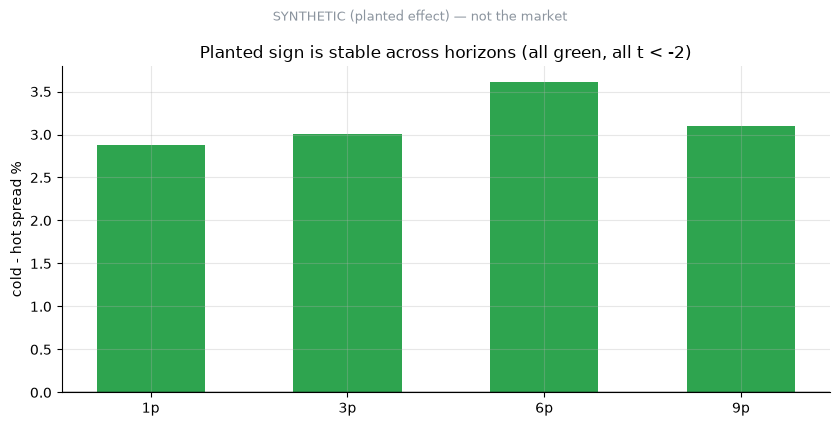

                 spread%  slope_t
horizon_periods                  
1                   2.88   -15.58
3                   3.01    -9.44
6                   3.61    -8.07
9                   3.10    -6.26


In [4]:
rows = st.horizon_sweep(data, BETA, horizons=(1,3,6,9))
tab = pd.DataFrame([(l, s*100, t) for (l,s,t) in rows],
                   columns=['horizon_periods','spread%','slope_t']).set_index('horizon_periods')
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in tab['spread%']]
ax.bar(range(len(tab)), tab['spread%'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels([f'{h}p' for h in tab.index])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('cold - hot spread %')
ax.set_title('Planted sign is stable across horizons (all green, all t < -2)')
fig.suptitle('SYNTHETIC (planted effect) — not the market', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: H₃ holds on the synthetic tape — the contrarian sign is stable and the slope-*t* stays past −2 from ~8h out to ~3 days. So the engine is not horizon-fragile. (Again: engine, not market.)

## 5 · The verdict

- **Signal `NONE`** — no real funding tape to test (paid data), so H₁–H₄ are **untested on the market**. The synthetic control clears every bar (spread +3.01%, slope *t* -9.44, placebo 0.0005, sign-stable, flat at null) — proving the engine, not the anomaly. House rule: synthetic-only caps below `REAL`.
- **Tradability `MIRAGE`** — 8-hourly rebalance, short leg pays the funding it keys on; synthetic gross +3.01% → net +2.47%.
- **Data-availability limitation** named openly on the Signal axis (like [273](../../273-lego-returns/) / [275](../../275-whisky-cask/) / [276](../../276-sneaker-resale/)).

## 6 · Could you trade it? — costs and the funding drag

Charge the synthetic spread per 8-hourly rebalance: a round-trip cost on each leg plus a punitive short-side **funding drag** (the hot short *pays* funding).

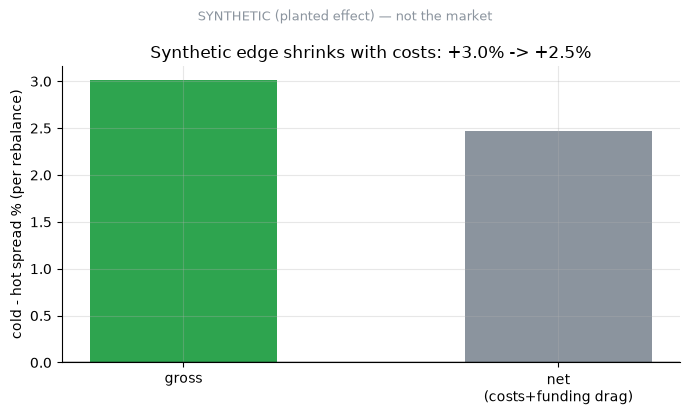

gross +3.0% -> net +2.5% (6 bps/leg + 30 bps funding drag, per 8h rebalance)


In [5]:
b = st.tail_buckets(PANEL)
gross = b['spread']*100
net = st.net_spread(b, cost_bps=6.0, funding_drag_bps=30.0)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+funding drag)'], [gross, net], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('cold - hot spread % (per rebalance)')
ax.set_title(f'Synthetic edge shrinks with costs: {gross:+.1f}% -> {net:+.1f}%')
fig.suptitle('SYNTHETIC (planted effect) — not the market', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (6 bps/leg + 30 bps funding drag, per 8h rebalance)')

> 💡 In plain words: even a *planted, clean* edge gives back a chunk to costs, and this is per-rebalance — three times a day. On a real, noisy funding tape (no planted effect) the net would be a small difference of large, expensive numbers. `MIRAGE`.

## 7 · Going further — the seed-robust synthetic control

Is the engine a faithful detector, or does it always print a signal? Plant a contrarian effect (`contrarian_beta < 0`) of increasing strength and watch the period-level slope-*t* go negative — **averaged over 25 seeds** so no single lucky seed can fake it (house rule).

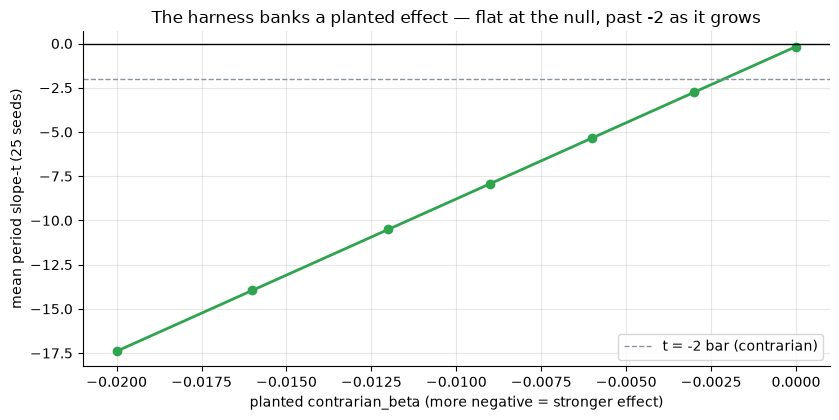

beta +0.000 -> mean slope-t -0.17
beta -0.003 -> mean slope-t -2.76
beta -0.006 -> mean slope-t -5.34
beta -0.009 -> mean slope-t -7.92
beta -0.012 -> mean slope-t -10.51
beta -0.016 -> mean slope-t -13.95
beta -0.020 -> mean slope-t -17.40


In [6]:
betas = [0.0, -0.003, -0.006, -0.009, -0.012, -0.016, -0.020]
ts = [st.synthetic_mean_t(data, contrarian_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (contrarian)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted contrarian_beta (more negative = stronger effect)')
ax.set_ylabel('mean period slope-t (25 seeds)')
ax.set_title('The harness banks a planted effect — flat at the null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'beta {b:+.3f} -> mean slope-t {t:+.2f}')

The slope-*t* is ≈ 0 at the null and falls past −2 as the planted effect grows — a faithful detector. So the study's limitation is the **missing real funding tape**, not a broken engine. The perp-funding contrarian idea stays `NONE` on this desk until someone pipes in a paid funding feed and clears *t* = 2 on the live market — after 8-hourly costs. For crypto signals we *can* test on free data, see [251 Crypto-Reversal](../../251-crypto-reversal/) and [325 Crypto-Fear-Greed](../../325-crypto-fear-greed/).